# Genetic Algorithm — Plasma Shape Optimisation

In [2]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import genetic_utils as gu
from pressure_utils import make_psi

warnings.filterwarnings('ignore', category=RuntimeWarning)

## Configuration

In [3]:
A      = -0.5
method = 'contour'
N_grid = 200

## Single warm-up run

In [4]:
num_generations = 10
population_size = 40

epsilon_range = (0.1,  0.45)
kappa_range   = (1.0,  1.7)
delta_range   = (-0.3, 0.3)

population   = gu.initialize_population(population_size, epsilon_range, kappa_range, delta_range)
best_params  = np.zeros(3)
best_fitness = -np.inf

for gen in range(num_generations):
    fitness = gu.evaluate_population(population, A=A, method=method, N=N_grid)

    gen_best_idx = np.argmax(fitness)
    if fitness[gen_best_idx] > best_fitness:
        best_fitness = fitness[gen_best_idx]
        best_params  = population[gen_best_idx].copy()

    print(f"gen {gen+1:3d}/{num_generations}  "
          f"best={best_fitness:.6f}  "
          f"mean={fitness.mean():.6f}  "
          f"(eps={best_params[0]:.3f}, kap={best_params[1]:.3f}, dlt={best_params[2]:.3f})")

    parents_a, parents_b = gu.select_parents(population, fitness, k=10)
    offspring            = gu.crossover(parents_a, parents_b, method='blx_alpha', alpha=0.05)
    mutated              = gu.mutate(offspring, 0.05, epsilon_range, kappa_range, delta_range)

    n_elite   = max(1, int(0.01 * population_size))
    elite_idx = np.argsort(fitness)[-n_elite:]
    mutated[:n_elite] = population[elite_idx]
    population = mutated

print()
print('\u2550' * 55)
print('Best individual found:')
print(f'  epsilon : {best_params[0]:.6f}')
print(f'  kappa   : {best_params[1]:.6f}')
print(f'  delta   : {best_params[2]:.6f}')
print(f'  fitness : {best_fitness:.6f}')
print('\u2550' * 55)

gen   1/10  best=0.042203  mean=0.015931  (eps=0.411, kap=1.413, dlt=0.139)
gen   2/10  best=0.050784  mean=0.033796  (eps=0.427, kap=1.624, dlt=0.045)
gen   3/10  best=0.057953  mean=0.042965  (eps=0.450, kap=1.614, dlt=-0.066)
gen   4/10  best=0.060826  mean=0.049494  (eps=0.448, kap=1.698, dlt=-0.300)
gen   5/10  best=0.061297  mean=0.051763  (eps=0.450, kap=1.698, dlt=-0.300)
gen   6/10  best=0.061297  mean=0.056602  (eps=0.450, kap=1.698, dlt=-0.300)
gen   7/10  best=0.061335  mean=0.049352  (eps=0.450, kap=1.700, dlt=-0.300)
gen   8/10  best=0.061335  mean=0.055179  (eps=0.450, kap=1.700, dlt=-0.300)
gen   9/10  best=0.061335  mean=0.058406  (eps=0.450, kap=1.700, dlt=-0.300)
gen  10/10  best=0.061335  mean=0.054802  (eps=0.450, kap=1.700, dlt=-0.300)

═══════════════════════════════════════════════════════
Best individual found:
  epsilon : 0.450000
  kappa   : 1.700000
  delta   : -0.300000
  fitness : 0.061335
═══════════════════════════════════════════════════════


## Multi-experiment comparison

Runs 4 configurations (varying population size and number of generations) and collects the best result from each.

In [5]:
def run_experiments(experiments, epsilon_range, kappa_range, delta_range,
                    A=A, method=method, N_grid=N_grid):
    """Run a list of GA experiments and return a results DataFrame."""
    results = []
    for exp_id, exp in enumerate(experiments, start=1):
        pop_size = exp['population_size']
        n_gen    = exp['num_generations']

        population   = gu.initialize_population(pop_size, epsilon_range, kappa_range, delta_range)
        best_params  = np.zeros(3)
        best_fitness = -np.inf

        for gen in range(n_gen):
            fitness = gu.evaluate_population(population, A=A, method=method, N=N_grid)

            gen_best_idx = np.argmax(fitness)
            if fitness[gen_best_idx] > best_fitness:
                best_fitness = fitness[gen_best_idx]
                best_params  = population[gen_best_idx].copy()

            parents_a, parents_b = gu.select_parents(population, fitness, k=10)
            offspring            = gu.crossover(parents_a, parents_b, method='blx_alpha', alpha=0.05)
            mutated              = gu.mutate(offspring, 0.05, epsilon_range, kappa_range, delta_range)

            n_elite   = max(1, int(0.01 * pop_size))
            elite_idx = np.argsort(fitness)[-n_elite:]
            mutated[:n_elite] = population[elite_idx]
            population = mutated

        results.append({
            'experiment':      exp_id,
            'population_size': pop_size,
            'num_generations': n_gen,
            'best_epsilon':    best_params[0],
            'best_kappa':      best_params[1],
            'best_delta':      best_params[2],
            'best_fitness':    best_fitness,
        })

    return pd.DataFrame(results)


experiments = [
    {'population_size': 20, 'num_generations': 10},
    {'population_size': 40, 'num_generations': 10},
    {'population_size': 60, 'num_generations': 10},
    {'population_size': 40, 'num_generations': 20},
]

### Tight parameter ranges

Search within physically motivated bounds for ITER-like configurations.

In [6]:
epsilon_range_tight = (0.1,  0.45)
kappa_range_tight   = (1.0,  1.7)
delta_range_tight   = (-0.3, 0.3)

results_tight = run_experiments(
    experiments,
    epsilon_range_tight, kappa_range_tight, delta_range_tight
)

results_tight.round(4)

,experiment,population_size,num_generations,best_epsilon,best_kappa,best_delta,best_fitness
0,1,20,10,0.4500,1.7000,-0.3000,0.0613
1,2,40,10,0.4500,1.7000,-0.3000,0.0613
2,3,60,10,0.4500,1.7000,-0.3000,0.0613
3,4,40,20,0.1138,1.1645,-0.2478,0.1649


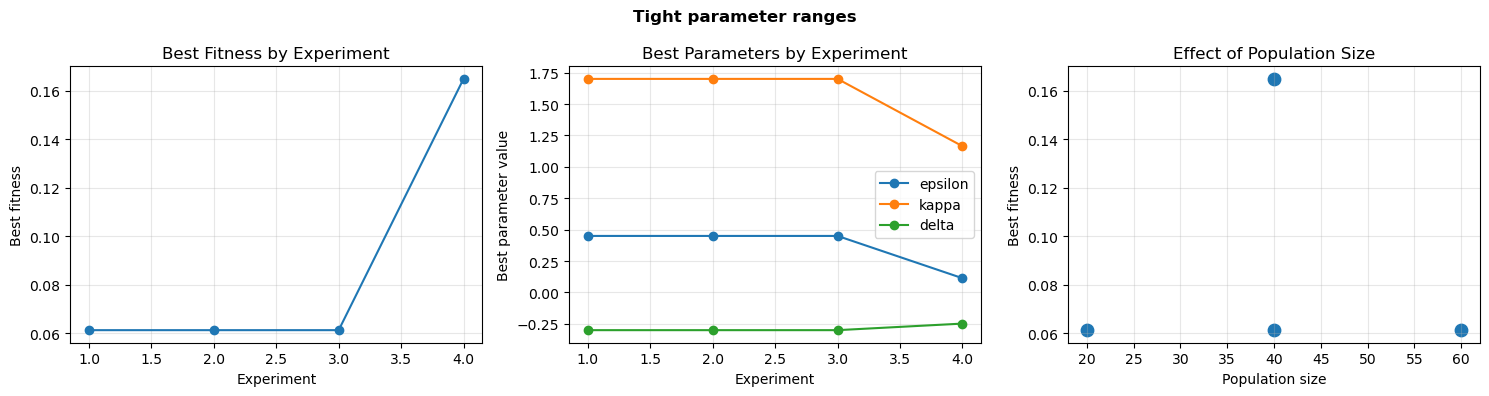

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_tight['experiment'], results_tight['best_fitness'], marker='o')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Best fitness')
axes[0].set_title('Best Fitness by Experiment')
axes[0].grid(True, alpha=0.3)

for col, label in [('best_epsilon', 'epsilon'), ('best_kappa', 'kappa'), ('best_delta', 'delta')]:
    axes[1].plot(results_tight['experiment'], results_tight[col], marker='o', label=label)
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Best parameter value')
axes[1].set_title('Best Parameters by Experiment')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(results_tight['population_size'], results_tight['best_fitness'], s=80)
axes[2].set_xlabel('Population size')
axes[2].set_ylabel('Best fitness')
axes[2].set_title('Effect of Population Size')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Tight parameter ranges', fontweight='bold')
plt.tight_layout()
plt.show()

### Wider parameter ranges

Expanded search space to explore more exotic configurations.

In [8]:
epsilon_range_wide = (0.05, 0.5)
kappa_range_wide   = (0.5,  2.0)
delta_range_wide   = (-0.5, 0.5)

results_wide = run_experiments(
    experiments,
    epsilon_range_wide, kappa_range_wide, delta_range_wide
)

results_wide.round(4)

,experiment,population_size,num_generations,best_epsilon,best_kappa,best_delta,best_fitness
0,1,20,10,0.05,0.5,-0.5,312.9307
1,2,40,10,0.05,0.5,-0.5,312.9307
2,3,60,10,0.05,0.5,-0.5,312.9307
3,4,40,20,0.05,0.5,-0.5,312.9307


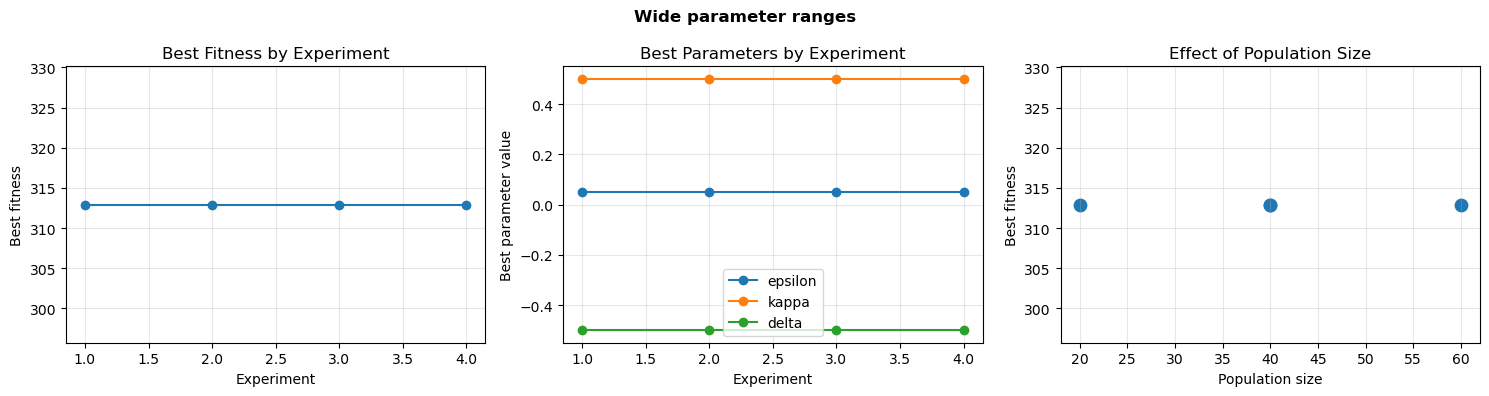

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_wide['experiment'], results_wide['best_fitness'], marker='o')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Best fitness')
axes[0].set_title('Best Fitness by Experiment')
axes[0].grid(True, alpha=0.3)

for col, label in [('best_epsilon', 'epsilon'), ('best_kappa', 'kappa'), ('best_delta', 'delta')]:
    axes[1].plot(results_wide['experiment'], results_wide[col], marker='o', label=label)
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Best parameter value')
axes[1].set_title('Best Parameters by Experiment')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(results_wide['population_size'], results_wide['best_fitness'], s=80)
axes[2].set_xlabel('Population size')
axes[2].set_ylabel('Best fitness')
axes[2].set_title('Effect of Population Size')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Wide parameter ranges', fontweight='bold')
plt.tight_layout()
plt.show()

## Plasma shape sanity check

Visualise the plasma boundary for the best individual found across all experiments.

Best parameters found:
  epsilon : 0.050000
  kappa   : 0.500000
  delta   : -0.500000
  fitness : 312.930678


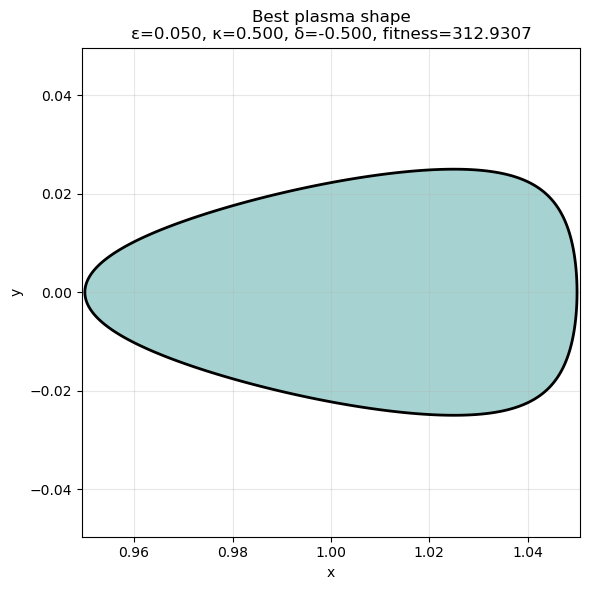

In [11]:
all_results = pd.concat([results_tight, results_wide], ignore_index=True)
best_row    = all_results.loc[all_results['best_fitness'].idxmax()]

epsilon = best_row['best_epsilon']
kappa   = best_row['best_kappa']
delta   = best_row['best_delta']

print(f'Best parameters found:')
print(f'  epsilon : {epsilon:.6f}')
print(f'  kappa   : {kappa:.6f}')
print(f'  delta   : {delta:.6f}')
print(f'  fitness : {best_row["best_fitness"]:.6f}')

psi, _, _ = make_psi(epsilon, kappa, delta, A=A)

# Grid bounded to the plasma extent — avoids spurious contours outside the domain
x = np.linspace(1 - epsilon, 1 + epsilon, 400)
y = np.linspace(-kappa * epsilon, kappa * epsilon, 400)
X, Y = np.meshgrid(x, y)
Z    = psi(X, Y)

plt.figure(figsize=(6, 6))
plt.contourf(X, Y, Z <= 0, levels=[0.5, 1], alpha=0.4)
plt.contour(X, Y, Z, levels=[0], colors='black', linewidths=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(
    f'Best plasma shape\n'
    f'\u03b5={epsilon:.3f}, \u03ba={kappa:.3f}, \u03b4={delta:.3f}, '
    f'fitness={best_row["best_fitness"]:.4f}'
)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Flux surface plot

Plot iso-flux contours (ψ = const) inside the plasma boundary for a specific equilibrium.

In [ ]:
epsilon =  0.1138
kappa   =  1.1645
delta   = -0.2478

psi, _, _ = make_psi(epsilon, kappa, delta, A=A)

# Grid bounded tightly to the plasma extent
x = np.linspace(1 - epsilon, 1 + epsilon, 600)
y = np.linspace(-kappa * epsilon, kappa * epsilon, 600)
X, Y = np.meshgrid(x, y)
Z    = psi(X, Y)

# Mask outside the plasma and find the magnetic axis value
Z_masked = np.where(Z <= 0, Z, np.nan)
psi_min  = float(np.nanmin(Z_masked))

# Contour levels from magnetic axis to boundary
levels = np.linspace(psi_min, 0, 15)

fig, ax = plt.subplots(figsize=(6, 7))
cf = ax.contourf(X, Y, Z_masked, levels=levels, cmap='plasma')
ax.contour(X, Y, Z_masked, levels=levels, colors='white', linewidths=0.6, alpha=0.5)
ax.contour(X, Y, Z,        levels=[0],    colors='black',  linewidths=2)
plt.colorbar(cf, ax=ax, label=r'$\psi$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Flux surfaces\n\u03b5={epsilon}, \u03ba={kappa}, \u03b4={delta}')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()